# Ensemble Methods — Wine Quality Classification

In this notebook you'll work through three ensemble strategies — voting, bagging, and boosting — applied to a real wine quality dataset. By the end you'll have trained four models and compared them directly.

## Part 1 — Load, Explore & Prepare

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

# Good wine = quality >= 7
df['is_good'] = (df['quality'] >= 7).astype(int)
df.drop(columns=['quality'], inplace=True)

print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,is_good
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


### TODO 1 — Explore the dataset

Understand what you're working with before building anything. Pay close attention to the target variable.

In [3]:
# TODO 1: Inspect the dataset — shape, missing values, distributions, and class balance.

df.info()


# Hint: With only ~13% of samples labeled as good wine, what would happen if a model
# simply predicted "not good" every single time?
# How would accuracy alone mislead you about whether the model is actually useful?

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  is_good               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,is_good
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,0.135710
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.342587
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,0.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,1.000000


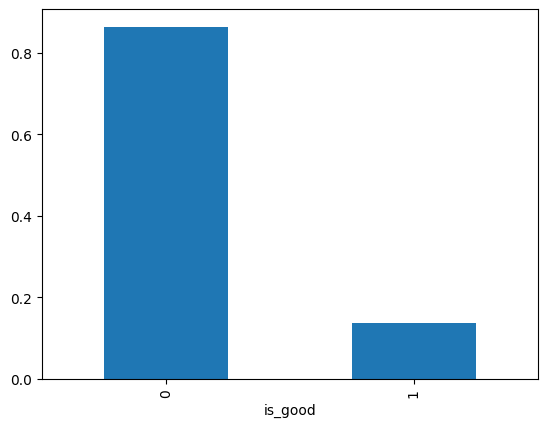

In [5]:
df.is_good.value_counts(normalize=True).plot.bar()
plt.show()

Accuracy alone is misleading because the total number of negative labeling is overwhelmingly more.

### TODO 2 — Train/test split

Split the data before any modeling. Think about whether a plain random split is appropriate given the class imbalance.

In [6]:
# TODO 2: Split the data into training and test sets.

from sklearn.model_selection import train_test_split


xtrain, xtest, ytrain, ytest = train_test_split(
    df.drop(columns="is_good"),
    df.is_good,
    stratify=df.is_good,
    test_size=0.2
)

# Hint: When one class is rare, a plain random split could leave very few
# positive examples in the test set by chance. Is there a way to preserve
# the class ratio across both halves?

---

## Part 2 — Baseline: Single Decision Tree

Before trying ensembles, you need something to compare against. A single decision tree is the natural baseline here because all three ensemble methods in this notebook build directly on top of decision trees. Train one, record the performance, and use it as your benchmark.

### TODO 3 — Single Decision Tree baseline

In [7]:
# TODO 3: Train a single decision tree and evaluate it on the test set.

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report


dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(xtrain, ytrain)

y_pred = dtree.predict(xtest)
print(classification_report(ytest, y_pred))


# Hint: Decision trees tend to memorize their training data.
# Focus on performance for the minority class — how does a tree that overfits
# behave when it encounters a rare pattern it hasn't seen before?

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       277
           1       0.51      0.56      0.53        43

    accuracy                           0.87       320
   macro avg       0.72      0.74      0.73       320
weighted avg       0.87      0.87      0.87       320



---

## Part 3 — Voting Classifier

A voting classifier combines several different algorithms and lets them vote on each prediction. Different algorithms make different kinds of mistakes, so a majority vote can cancel out individual errors. You choose which models to include and how the vote is counted.

### TODO 4 — Voting Classifier

Combine at least three different base models and compare the result to your decision tree baseline.

In [8]:
# TODO 4: Build a voting classifier from at least three different algorithms,
# train it, and evaluate it against the baseline.

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Distance-based models need feature scaling
voting = VotingClassifier(estimators=[
    ('lgr', make_pipeline(StandardScaler(), LogisticRegression(random_state=42))),
    ('svc', make_pipeline(StandardScaler(), SVC(random_state=42))),
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier()))
], voting='hard')

voting.fit(xtrain, ytrain)
y_pred_voting = voting.predict(xtest)
print(classification_report(ytest, y_pred_voting))


# Hint: Ensembles work best when base models are diverse — they should look at
# the problem from fundamentally different angles and fail on different examples.
# What makes Logistic Regression, SVC, and KNN each approach the data differently?

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       277
           1       0.71      0.28      0.40        43

    accuracy                           0.89       320
   macro avg       0.80      0.63      0.67       320
weighted avg       0.87      0.89      0.87       320



- Logistic regression plots a linear regression than applies a sigmoid function to split in two halves. Looks at the trend in the data first. -> fails when boundary is non-linear
- KNN looks at n neighbors of data points to determine which class it belongs to. -> fails when boundary is noisy, high dimensions and imbalanced data
- SVM looks at the maximum distance possible between points to draw a line and allocate class. -> fails with large dataset and heavy noise around boundaries


### TODO 5 — Reflect

**Question:** Did the voting classifier outperform the single decision tree? On which metric? Why might combining different algorithms help even if each individual one isn't great?

*Your answer here.*
Voting classifier actually performed much worse on recall and f-1 score for the imbalanced class. Precision improved by 8%.

Combining algos can help because they have different points of failures, however the selected algos all suffer from majority bias. Since the key issue here is imbalanced data, ensemble alone does not provide much help. We would need hyper-parameter tuning.

---

## Part 4 — Bagging: Random Forest

Random Forest uses the same base learner as the single tree but creates diversity through randomness — each tree sees a different bootstrap sample of rows and a random subset of features at each split. This is bagging (Bootstrap AGGregatING), and it dramatically reduces the overfitting that plagues a single tree.

### TODO 6 — Random Forest

Train a Random Forest and compare it to both the single tree and the voting classifier.

In [9]:
# TODO 6: Train a RandomForestClassifier and evaluate it on the test set.

from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(random_state=42)
rf.fit(xtrain, ytrain)

y_pred_rf = rf.predict(xtest)
print(classification_report(ytest, y_pred_rf))


# Hint: Each tree in the forest sees less information than a single tree trained
# on the full dataset. Why would deliberately giving each learner less data
# lead to a better result when you combine them?

              precision    recall  f1-score   support

           0       0.92      0.98      0.95       277
           1       0.80      0.47      0.59        43

    accuracy                           0.91       320
   macro avg       0.86      0.72      0.77       320
weighted avg       0.91      0.91      0.90       320



### TODO 7 — Hyperparameter experiment

Pick at least one hyperparameter and run the model at least twice with different values. Observe how performance changes.

In [10]:
# TODO 7: Train Random Forest with at least two different hyperparameter settings.
# Print the key metric for each run so you can compare.


rf = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')
rf.fit(xtrain, ytrain)

y_pred_rf = rf.predict(xtest)
print(classification_report(ytest, y_pred_rf))

# Hint: The most natural knobs are how many trees to build and how deep
# each tree is allowed to grow. At what point does adding more trees
# stop meaningfully improving results?

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       277
           1       0.88      0.53      0.67        43

    accuracy                           0.93       320
   macro avg       0.91      0.76      0.81       320
weighted avg       0.93      0.93      0.92       320



In [11]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=150, min_samples_split=4)
rf.fit(xtrain, ytrain)

y_pred_rf = rf.predict(xtest)
print(classification_report(ytest, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       277
           1       0.85      0.51      0.64        43

    accuracy                           0.92       320
   macro avg       0.89      0.75      0.80       320
weighted avg       0.92      0.92      0.91       320



### TODO 8 — Reflect

**Question:** How does Random Forest compare to the single decision tree? Why does training many trees on random subsets produce a better result than one tree on all the data?

*Your answer here.*
Random Forest performs best of all so far, with decent precision, and the highest f1-score. Many tries of different samples help averaging out the imbalance, since each tree looks at a different subsample and the classes will have different balance in each.

---

## Part 5 — Boosting: XGBoost

Boosting trains trees sequentially — each new tree focuses on correcting the mistakes the current ensemble already makes. Rather than averaging independent trees, they build on each other's failures. XGBoost is the dominant gradient boosting library: fast, regularized, and a consistent winner on structured data problems.

### TODO 9 — XGBoost

Train an XGBClassifier and compare it to all previous models. This dataset is imbalanced — think about whether that's something you can communicate to the model.

In [12]:
# TODO 9: Train an XGBClassifier and evaluate it on the test set.

from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, scale_pos_weight=8)
xgb.fit(xtrain, ytrain)

y_pred_xgb = xgb.predict(xtest)
print(classification_report(ytest, y_pred_xgb))


# Hint: The dataset has roughly 8 negative examples for every positive one.
# Some algorithms accept a parameter that tells them exactly how much more
# attention to pay to the minority class. What ratio would make sense here?

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       277
           1       0.61      0.72      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.82      0.80       320
weighted avg       0.91      0.90      0.90       320



### TODO 10 — Learning rate experiment

Try at least two different values of the learning rate and observe how model performance changes.

In [13]:
# TODO 10: Train XGBoost at least twice with different learning_rate values.
# Record how performance changes each time.

xgb_slow = XGBClassifier(random_state=42, scale_pos_weight=8, learning_rate=0.01)
xgb_slow.fit(xtrain, ytrain)
print(classification_report(ytest, xgb_slow.predict(xtest)))


# Hint: The learning rate controls how big a correction each new tree makes.
# A large rate converges quickly but risks jumping past the optimum.
# A small rate is more careful but may never get there with few trees.
# What tradeoff are you making?

              precision    recall  f1-score   support

           0       0.97      0.83      0.89       277
           1       0.42      0.81      0.56        43

    accuracy                           0.82       320
   macro avg       0.69      0.82      0.72       320
weighted avg       0.89      0.82      0.85       320



In [14]:
xgb_fast = XGBClassifier(random_state=42, scale_pos_weight=8, learning_rate=0.3)
xgb_fast.fit(xtrain, ytrain)
print(classification_report(ytest, xgb_fast.predict(xtest)))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94       277
           1       0.61      0.72      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.82      0.80       320
weighted avg       0.91      0.90      0.90       320



### TODO 11 — Reflect

**Question:** How does XGBoost compare to Random Forest? Both use decision trees — what is fundamentally different about how they combine them?

*Your answer here.*

---

## Part 6 — Compare All Models

Replace the placeholder variable names below with your actual prediction arrays from earlier in the notebook, then run the cell.

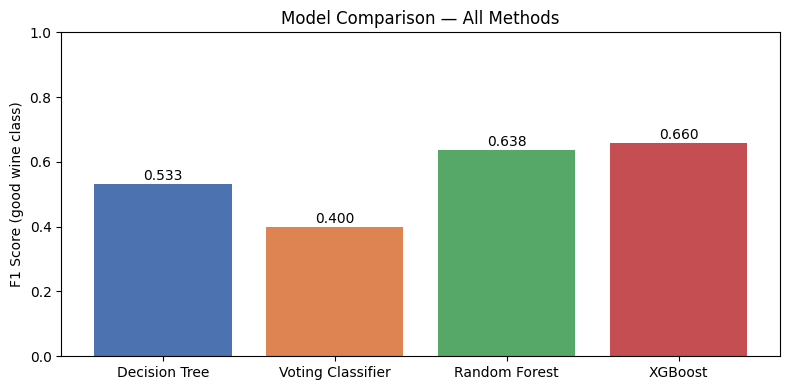

In [15]:
from sklearn.metrics import f1_score

# Replace each placeholder with your actual prediction variable name from above
model_scores = {
    'Decision Tree':     f1_score(ytest, y_pred),
    'Voting Classifier': f1_score(ytest, y_pred_voting),
    'Random Forest':     f1_score(ytest, y_pred_rf),
    'XGBoost':           f1_score(ytest, y_pred_xgb),
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(model_scores.keys(), model_scores.values(),
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_ylabel('F1 Score (good wine class)')
ax.set_title('Model Comparison — All Methods')
ax.set_ylim(0, 1)
for bar, v in zip(bars, model_scores.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
            f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### TODO 12 — Final reflection

*Replace this cell with your answer.*

Which model performed best? Was the improvement from ensembles worth the added complexity? In what real-world scenario would you pick Random Forest over XGBoost, or the other way around?

The Random Forest and XGBoost perform best, but the key has been rebalancing the dataset.

Pick Random Forest when:
- You need a quick, robust baseline with minimal tuning
- Interpretability matters — feature importance is straightforward
- Dataset is small/medium, training speed is a concern
- Noisy data — RF is more robust, XGBoost can overfit noise

Pick XGBoost when:
- You need maximum predictive performance
- Dataset is large and structured (tabular)
- You have time to tune hyperparameters
- Imbalanced classes — scale_pos_weight is more powerful than RF's class_weight